# Notebook 3: Building Network and Detecting Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import community as community_louvain
import leidenalg as la
import igraph as ig
from collections import Counter
import time
import os

In [2]:
edges = pd.read_csv("outputs/network_edges.tsv", sep="\t")

In [3]:
edges.head()

,protein_A,protein_B,spearman_rho
0,FGB,FGG,0.993813
1,SPTA1,SPTB,0.989519
2,SPTAN1,SPTBN1,0.988788
3,EPB42,SLC4A1,0.987211
4,FLOT1,FLOT2,0.986896


In [4]:
data = pd.read_csv("outputs/data_imputed.tsv", sep = '\t', index_col = 0)

In [5]:
data.head()

,Patient_1,Patient_2,Patient_3,Patient_4,Patient_5,Patient_6,Patient_7,Patient_8,Patient_9,Patient_10,...,Patient_109,Patient_110,Patient_111,Patient_112,Patient_113,Patient_114,Patient_115,Patient_116,Patient_117,Patient_118
A1BG,-0.248427,0.342380,-0.422836,0.523159,0.838483,0.104756,0.152693,-0.307978,0.015145,-0.250013,...,0.604403,0.120395,0.276506,-0.224080,-0.193982,0.258954,0.061537,0.370149,0.490885,0.185676
A2M,-1.204522,-0.329580,-0.680533,0.075529,1.109671,-0.513389,-0.064456,-1.147968,-0.035746,-1.178612,...,0.886675,-0.689876,0.328976,-0.685488,-1.077732,-0.347891,-0.466748,1.296028,1.295298,-0.273764
AAAS,0.250455,-0.042588,0.123734,0.262234,0.166103,0.104671,0.084311,0.032663,0.266344,0.269713,...,0.105247,-0.110949,-0.076646,-0.017859,0.104261,0.121138,0.102050,0.356460,-0.087324,0.542225
AACS,0.332777,0.801353,0.620108,-0.028909,0.205515,-0.288173,0.173700,-0.019604,-0.300753,-0.527521,...,-0.088388,-0.299584,-0.115912,-0.214156,0.067791,0.087183,0.855150,0.455009,0.241351,0.095773
AADAT,-0.865041,-1.460905,-1.188897,-1.290277,-1.554209,-1.602774,-1.425772,-1.342417,-1.583921,-0.082984,...,0.336694,-0.496572,-0.521811,-0.267679,1.717657,0.187466,-0.054714,-0.141242,-0.361436,-0.205090


In [6]:
edges.shape, data.shape

((8987, 3), (10164, 118))

 ## STEP 1: BUILDING NETWORK

In [7]:
G = nx.from_pandas_edgelist(
    edges,
    source = "protein_A",
    target = "protein_B",
    edge_attr = "spearman_rho"
)

In [8]:
print(G)

Graph with 1658 nodes and 8987 edges


In [9]:
print("=== PPI NETWORK OVERVIEW ===")

print(f"Total proteins (nodes): {G.number_of_nodes():,}")
print(f"Total interactions (edges): {G.number_of_edges():,}")

# checking whether the network is fully connected or split into groups
n_components = nx.number_connected_components(G)
print(f"Disconnected groups (components): {n_components}")

# largest connected group of proteins
gcc_nodes = max(nx.connected_components(G), key=len)
GCC = G.subgraph(gcc_nodes).copy()

print(
    f"Largest protein group (Giant Connected Component): "
    f"{GCC.number_of_nodes():,} proteins "
    f"({GCC.number_of_nodes()/G.number_of_nodes()*100:.1f}% of all proteins)"
)

# how densely proteins are connected
print(f"Network density: {nx.density(G):.4f}")

=== PPI NETWORK OVERVIEW ===
Total proteins (nodes): 1,658
Total interactions (edges): 8,987
Disconnected groups (components): 184
Largest protein group (Giant Connected Component): 449 proteins (27.1% of all proteins)
Network density: 0.0065


In [10]:
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f"Average Degree: {avg_degree:.2f}")

Average Degree: 10.84


## STEP 2: FINDING HUB PROTEINS

In [11]:
degrees = dict(G.degree())
list(degrees.items())[:5]

[('FGB', 2), ('FGG', 2), ('SPTA1', 22), ('SPTB', 21), ('SPTAN1', 1)]

In [12]:
top_hubs = sorted(degrees.items(), key = lambda x: x[1], reverse = True)[:10]
# top_hubs

In [13]:
for protein, connections in top_hubs:
    print(f"{protein}: {connections} interactions")

DDX17: 96 interactions
SF3B2: 89 interactions
TOP2A: 87 interactions
KIF2C: 85 interactions
U2AF2: 85 interactions
KIF11: 84 interactions
KIF22: 83 interactions
TTK: 83 interactions
CENPF: 80 interactions
HMMR: 80 interactions


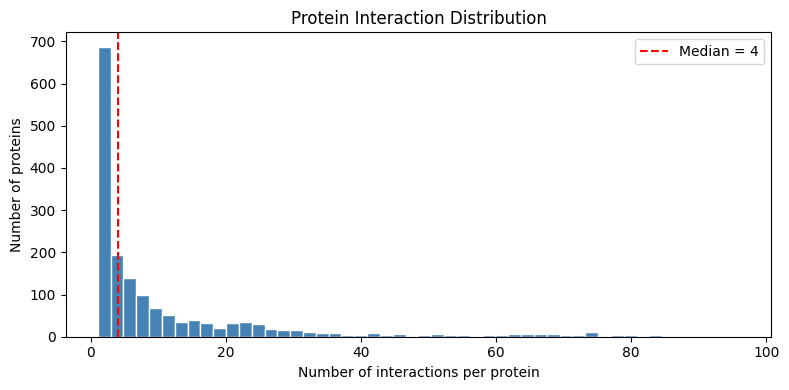

=== CONNECTION SUMMARY ===
Average interactions per protein: 11
Median interactions per protein:  4
Highest interactions observed:    96


In [14]:
# number of connections of each protein
degree_values = list(degrees.values())

# plot distribution of protein connections
plt.figure(figsize=(8, 4))

plt.hist(
    degree_values,
    bins=50,
    color='steelblue',
    edgecolor='white'
)

plt.xlabel("Number of interactions per protein")
plt.ylabel("Number of proteins")
plt.title("Protein Interaction Distribution")

# adding median reference line
median_degree = np.median(degree_values)

plt.axvline(
    median_degree,
    color='red',
    linestyle='--',
    label=f"Median = {median_degree:.0f}"
)

plt.legend()

plt.tight_layout()
plt.show()

print("=== CONNECTION SUMMARY ===")
print(f"Average interactions per protein: {np.mean(degree_values):.0f}")
print(f"Median interactions per protein:  {np.median(degree_values):.0f}")
print(f"Highest interactions observed:    {max(degree_values):,}")

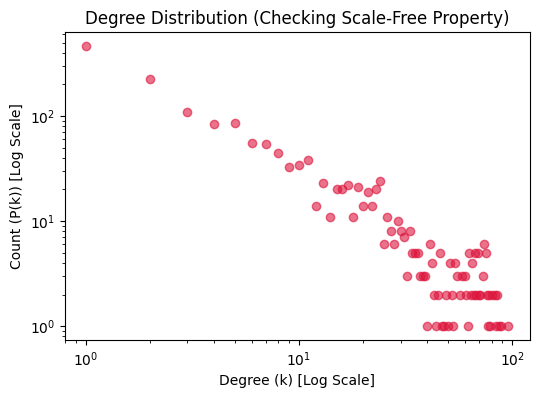

Power Law Exponent (Gamma): 1.38
R-squared fit: 0.8505


In [15]:
import collections
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# 1. Get degree sequence
degrees = [d for n, d in G.degree()]
degree_counts = collections.Counter(degrees)
k, P_k = zip(*degree_counts.items())

# 2. Plot Log-Log
plt.figure(figsize=(6, 4))
plt.scatter(k, P_k, color='crimson', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree (k) [Log Scale]')
plt.ylabel('Count (P(k)) [Log Scale]')
plt.title('Degree Distribution (Checking Scale-Free Property)')
plt.show()

# 3. Quick mathematical check using linear regression on log data
log_k = np.log10(k)
log_Pk = np.log10(P_k)
slope, intercept, r_value, p_value, std_err = stats.linregress(log_k, log_Pk)
gamma = -slope

print(f"Power Law Exponent (Gamma): {gamma:.2f}")
print(f"R-squared fit: {r_value**2:.4f}")

## STEP 3: COMMUNITY DETECTION

### (a). Louvain Algorithm

In [53]:
# Louvain algorithm
print("Louvain community detection started")

start_time = time.perf_counter()

# detecting protein communities/modules
louvain_partition = community_louvain.best_partition(GCC)

end_time = time.perf_counter()
time_taken = end_time - start_time

print(f"Time taken by Louvain algorithm:{time_taken:.4f} seconds ")

Louvain community detection started
Time taken by Louvain algorithm:0.1158 seconds 


In [54]:
# total number of communities found
num_communities_louvain = len(set(louvain_partition.values()))

# measure how well-separated the communities are
modularity_score_louvain = community_louvain.modularity(
    louvain_partition,
    GCC
)

print(f"Number of communities: {num_communities_louvain}")
print(f"Modularity score:{modularity_score_louvain:.4f}")

Number of communities: 16
Modularity score:0.4947


In [55]:
# count proteins inside each community
community_sizes = Counter(louvain_partition.values())

# sort from largest to smallest
community_sizes_louvain = sorted(
    community_sizes.values(),
    reverse=True
)

print("\nLargest community sizes:")
print(community_sizes_louvain[:10])


Largest community sizes:
[130, 106, 96, 30, 24, 19, 8, 7, 6, 5]


### (b). Leiden Algrithm

In [56]:
# Leiden algorithm
print("Leiden community detection started")

# Convert NetworkX graph into igraph format
# Because Leiden works with igraph

# creating a list of proteins
protein_list = list(GCC.nodes())

# assign a numeric ID for each protein
protein_to_id = {
    protein: idx
    for idx, protein in enumerate(protein_list)
}

# converting protein edges into numeric edges
igraph_edges = [(protein_to_id[u], protein_to_id[v]) for u, v in GCC.edges() ]

# creating igraph network
g_ig = ig.Graph(
    n=len(protein_list),
    edges=igraph_edges
)

start_time = time.perf_counter()

# detect communities/modules
leiden_result = la.find_partition(
    g_ig,
    la.ModularityVertexPartition
)

end_time = time.perf_counter()
time_taken = end_time - start_time
print(f"Time taken by Louvain algorithm:{time_taken:.4f} seconds ")

Leiden community detection started
Time taken by Louvain algorithm:0.0263 seconds 


In [57]:
# leiden_result[0]

In [58]:
# Convert results back to protein names
leiden_assignment = {}
for community_id, community in enumerate(leiden_result):
    for protein_idx in community:
        protein_name = protein_list[protein_idx]
        leiden_assignment[protein_name] = community_id

# number of detected communities
num_communities_leiden = len(leiden_result)

# community quality score
modularity_score_leiden = leiden_result.modularity

# size of each community
community_sizes_leiden = sorted(
    [len(c) for c in leiden_result],
    reverse=True
)

print(f"Number of communities:{num_communities_leiden}")
print(f"Modularity score:{modularity_score_leiden:.4f}")

print("\nLargest community sizes:")
print(community_sizes_leiden[:10])

Number of communities:14
Modularity score:0.4944

Largest community sizes:
[116, 96, 95, 47, 24, 19, 16, 8, 7, 6]


## STEP 4: EXPLORING MODULES FOUND BY LEIDEN

In [59]:
selected_module = leiden_assignment
selected_method = "Leiden"

print(f"Using {selected_method} communities.")

# creating a table:
# protein -> module ID
module_df = pd.DataFrame(selected_module.items(), columns=["protein", "module_id"])
# module_df.head()

Using Leiden communities.


In [60]:
# counting proteins inside each module
module_sizes = (module_df.groupby("module_id").size().sort_values(ascending=False))

# Renaming modules so:
# Module 0 = largest module, Module 1 = second largest and so on
new_module_ids = {}
for new_id, old_id in enumerate(module_sizes.index):
    new_module_ids[old_id] = new_id

module_df["module_id"] = (module_df["module_id"].map(new_module_ids))

# saving our results
module_df.to_csv("outputs/module_assignments.tsv", sep="\t", index=False)

print(f"Saved module assignments for {len(module_df):,} proteins")

Saved module assignments for 449 proteins


In [61]:
module_df.head()

,protein,module_id
0,THAP11,0
1,EWSR1,0
2,FUBP1,0
3,U2AF2,0
4,DDX39B,0


In [62]:
print("Proteins per module:")
print(module_df.groupby("module_id").size().to_string())

Proteins per module:
module_id
0     116
1      96
2      95
3      47
4      24
5      19
6      16
7       8
8       7
9       6
10      5
11      5
12      3
13      2


In [63]:
print("TOP HUB PROTEINS IN EACH MODULE")
for module_id in sorted(module_df["module_id"].unique()):
    # get proteins belonging to this module
    module_proteins = module_df[module_df["module_id"] == module_id]["protein"].tolist()

    # get interaction counts for proteins in this module
    protein_connections = {}
    for protein in module_proteins:
        protein_connections[protein] = degrees.get(protein, 0)

    # choosing top 10 most connected proteins
    top_hubs = sorted(protein_connections.items(), key=lambda x: x[1], reverse=True)[:10]

    # converting to readable text
    top_hub_names = ", ".join(protein for protein, connections in top_hubs)

    print(f"Module {module_id}: {len(module_proteins):,} proteins")
    print(f"Top hub proteins: {top_hub_names}\n")


TOP HUB PROTEINS IN EACH MODULE
Module 0: 116 proteins
Top hub proteins: DDX17, U2AF2, ACTL6A, NCL, SNRNP70, KHDRBS1, SNRPA1, ADNP, HNRNPR, SAFB

Module 1: 96 proteins
Top hub proteins: NIFK, PDCD11, NOL6, MPHOSPH10, RCL1, DDX27, DDX10, BMS1, CEBPZ, NOC2L

Module 2: 95 proteins
Top hub proteins: SF3B2, CDC5L, YLPM1, SF3A3, THRAP3, SRSF6, IK, ZC3H13, PRPF4B, TRA2B

Module 3: 47 proteins
Top hub proteins: CHD4, SMARCA2, KDM1A, SMARCC2, SMARCE1, SMARCD2, SMARCB1, MBD3, EHMT1, LYL1

Module 4: 24 proteins
Top hub proteins: NOP56, NOP58, GAR1, FAM98B, DDX1, DKC1, LAS1L, FBL, ZNF512, WDR18

Module 5: 19 proteins
Top hub proteins: SNRNP200, DDX23, SYMPK, MED24, EFTUD2, PRPF8, PRPF6, SAP18, MED14, USP39

Module 6: 16 proteins
Top hub proteins: POLR1A, POLR1B, POLR3D, POLR3A, POLR1E, TWISTNB, POLR1C, POLR2E, POLR3B, ZMYM4

Module 7: 8 proteins
Top hub proteins: ALYREF, CHTOP, LLPH, ZRANB2, C11orf98, CCDC137, TAF3, FYTTD1

Module 8: 7 proteins
Top hub proteins: NUP153, SCAF8, SON, RBM14, ZC3H14, 

## STEP 5: VISUALIZATION

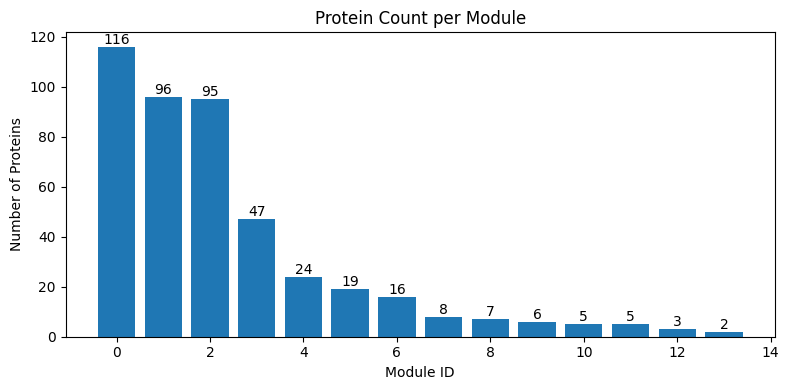

In [64]:
# create the folder if it does not exist
os.makedirs("outputs/figures", exist_ok=True)

# count proteins in each module
module_sizes = (module_df.groupby("module_id").size())

# creating a bar plot
plt.figure(figsize=(8, 4))
bars = plt.bar(module_sizes.index,module_sizes.values)

# adding protein counts above bars
for bar, count in zip(bars, module_sizes.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Module ID")
plt.ylabel("Number of Proteins")
plt.title("Protein Count per Module")
plt.tight_layout()

plt.savefig("outputs/figures/module_sizes.png", dpi=150)

plt.show()

In [65]:
# saving network data

node_records = []
for protein in G.nodes():
    node_records.append({
        'protein': protein,
        'degree': degrees[protein],
        'module_id': selected_module.get(protein, -1)  # -1 would mean not in GCC
    })

node_df = pd.DataFrame(node_records)

# sort by most connected proteins
node_df = node_df.sort_values("degree", ascending=False)
node_df.to_csv("outputs/network_nodes.tsv", sep="\t",index=False)

print(f"Saved node table to outputs/network_nodes.tsv ({len(node_df):,} proteins)")

Saved node table to outputs/network_nodes.tsv (1,658 proteins)
